In [35]:
# Objective
print("Objective")
print('''To perform sentiment analysis on Twitter data by analyzing tweets
and classifying their sentiment as Positive, Negative, or Neutral.
The analysis aims to understand the distribution of sentiments and
build a machine learning model to predict the sentiment of tweets.''')

# Dataset Description
print("Description")
print('''The Twitter Sentiment Analysis dataset contains tweets along with
the entities they refer to and their corresponding sentiment labels.

The dataset contains three sentiment classes:
- Positive
- Negative
- Neutral

The task is to determine the sentiment of a tweet with respect to
a particular entity. This dataset is useful for understanding
public opinions and applying natural language processing and
machine learning techniques to text data.''')

Objective
To perform sentiment analysis on Twitter data by analyzing tweets
and classifying their sentiment as Positive, Negative, or Neutral.
The analysis aims to understand the distribution of sentiments and
build a machine learning model to predict the sentiment of tweets.
Description
The Twitter Sentiment Analysis dataset contains tweets along with
the entities they refer to and their corresponding sentiment labels.

The dataset contains three sentiment classes:
- Positive
- Negative
- Neutral

The task is to determine the sentiment of a tweet with respect to
a particular entity. This dataset is useful for understanding
public opinions and applying natural language processing and
machine learning techniques to text data.


In [36]:
# ============================================
# TASK 04: Twitter Sentiment Analysis
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Extract the ZIP file
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("twitter_sentiment_data")

print("Files extracted successfully!")
print("\nFiles inside the extracted folder:")

for root, dirs, filenames in os.walk("twitter_sentiment_data"):
    for filename in filenames:
        print(os.path.join(root, filename))

Saving archive.zip to archive (1).zip
Files extracted successfully!

Files inside the extracted folder:
twitter_sentiment_data/twitter_validation.csv
twitter_sentiment_data/twitter_training.csv


In [37]:
# --------------------------------------------
# 3. Load the Twitter Training Dataset
# --------------------------------------------

training_file = "twitter_sentiment_data/twitter_training.csv"

df = pd.read_csv(training_file, header=None)

print("\nDataset loaded successfully!")

print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully!

First 5 rows:


,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [38]:
# --------------------------------------------
# 4. Assign Column Names
# --------------------------------------------

df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

print("\nColumn names assigned successfully!")
print(df.columns.tolist())


Column names assigned successfully!
['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']


In [39]:
# --------------------------------------------
# 5. Display Dataset Information
# --------------------------------------------

print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [40]:
# --------------------------------------------
# 6. Display Dataset Shape
# --------------------------------------------

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset Shape:
Rows: 74682
Columns: 4


In [41]:
# --------------------------------------------
# 7. Check Missing Values
# --------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64


In [42]:
# --------------------------------------------
# 8. Check Duplicate Rows
# --------------------------------------------

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
2700


In [43]:
# --------------------------------------------
# 9. Clean Missing Values and Duplicates
# --------------------------------------------

print("Rows before cleaning:", len(df))

# Remove rows with missing Tweet values
df = df.dropna(subset=["Tweet"])

# Remove duplicate rows
df = df.drop_duplicates()

print("Rows after cleaning:", len(df))

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

Rows before cleaning: 74682
Rows after cleaning: 71656

Missing Values After Cleaning:
Tweet_ID     0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

Duplicate Rows After Cleaning:
0


In [44]:
# --------------------------------------------
# 10. Sentiment Distribution
# --------------------------------------------

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

print("\nSentiment Percentages:")
print(df["Sentiment"].value_counts(normalize=True) * 100)


Sentiment Distribution:
Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

Sentiment Percentages:
Sentiment
Negative      30.280786
Positive      27.510606
Neutral       24.712515
Irrelevant    17.496092
Name: proportion, dtype: float64


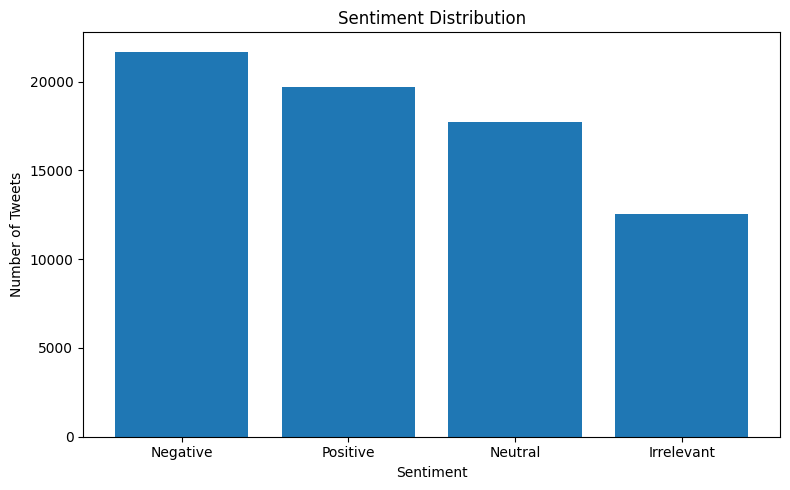

In [45]:
# --------------------------------------------
# 11. Visualize Sentiment Distribution
# --------------------------------------------

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.title("Sentiment Distribution")

plt.tight_layout()
plt.show()

In [46]:
# --------------------------------------------
# 12. Clean Tweet Text
# --------------------------------------------

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # Remove URLs
    text = re.sub(r"@\w+", "", text)                # Remove mentions
    text = re.sub(r"#", "", text)                   # Remove hashtag symbol
    text = re.sub(r"[^a-zA-Z\s]", "", text)         # Remove special characters
    text = re.sub(r"\s+", " ", text).strip()        # Remove extra spaces
    return text

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

print("Tweet text cleaning completed!")
display(df[["Tweet", "Clean_Tweet"]].head())

Tweet text cleaning completed!


,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...


In [47]:
# --------------------------------------------
# 13. Remove Empty Tweets
# --------------------------------------------

print("Rows before removing empty tweets:", len(df))

df = df[df["Clean_Tweet"].str.strip() != ""]

print("Rows after removing empty tweets:", len(df))

Rows before removing empty tweets: 71656
Rows after removing empty tweets: 71315


In [48]:
# --------------------------------------------
# 14-15. Encode Sentiment and Prepare Target
# --------------------------------------------

from sklearn.preprocessing import LabelEncoder

# Remove any rows where sentiment is missing
df = df.dropna(subset=["Sentiment"]).copy()

# Encode all sentiment categories
label_encoder = LabelEncoder()
df["Sentiment_Label"] = label_encoder.fit_transform(df["Sentiment"])

# Prepare features and target
X = df["Clean_Tweet"]
y = df["Sentiment_Label"]

print("Sentiment classes:", list(label_encoder.classes_))
print("Number of tweets:", len(X))
print("Number of labels:", len(y))
print("Missing labels:", y.isna().sum())

Sentiment classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Number of tweets: 71315
Number of labels: 71315
Missing labels: 0


In [49]:
# --------------------------------------------
# 16. Convert Text into TF-IDF Features
# --------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF conversion completed!")
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF conversion completed!
TF-IDF matrix shape: (71315, 5000)


In [50]:
# --------------------------------------------
# 17. Split Data into Training and Testing Sets
# --------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split completed!
Training samples: 57052
Testing samples: 14263


In [51]:
# --------------------------------------------
# 18. Create Logistic Regression Model
# --------------------------------------------

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [52]:
# --------------------------------------------
# 19. Train the Model
# --------------------------------------------

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [53]:
# --------------------------------------------
# 20. Make Predictions
# --------------------------------------------

y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 10 predictions:", y_pred[:10])

Predictions completed!
First 10 predictions: [0 3 0 1 2 3 0 2 1 3]


In [54]:
# --------------------------------------------
# 21. Calculate Model Accuracy
# --------------------------------------------

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:")
print(f"{accuracy * 100:.2f}%")

Logistic Regression Accuracy:
67.95%


In [55]:
# --------------------------------------------
# 22. Classification Report
# --------------------------------------------

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.65      0.51      0.57      2495
    Negative       0.68      0.79      0.73      4321
     Neutral       0.68      0.63      0.65      3518
    Positive       0.69      0.71      0.70      3929

    accuracy                           0.68     14263
   macro avg       0.68      0.66      0.66     14263
weighted avg       0.68      0.68      0.68     14263



In [56]:
# --------------------------------------------
# 23. Confusion Matrix
# --------------------------------------------

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1262  456  328  449]
 [ 207 3429  336  349]
 [ 248  605 2199  466]
 [ 216  528  383 2802]]


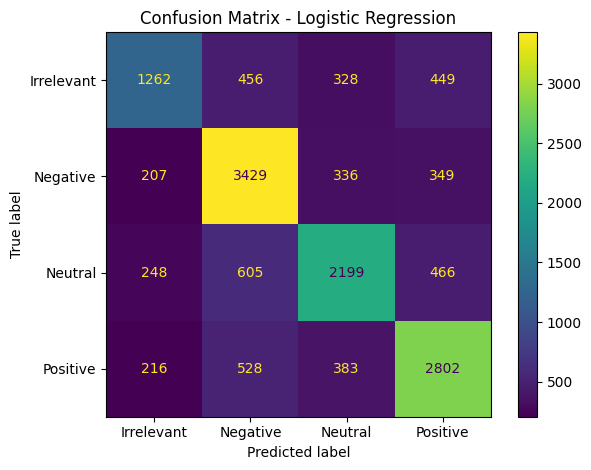

In [57]:
# --------------------------------------------
# 24. Confusion Matrix Visualization
# --------------------------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [58]:
# --------------------------------------------
# 25. Actual vs Predicted Sentiments
# --------------------------------------------

comparison = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

print("Actual vs Predicted:")
display(comparison.head(10))

Actual vs Predicted:


,Actual,Predicted
0,Irrelevant,Irrelevant
1,Irrelevant,Positive
2,Irrelevant,Irrelevant
3,Negative,Negative
4,Neutral,Neutral
5,Irrelevant,Positive
6,Irrelevant,Irrelevant
7,Neutral,Neutral
8,Negative,Negative
9,Irrelevant,Positive


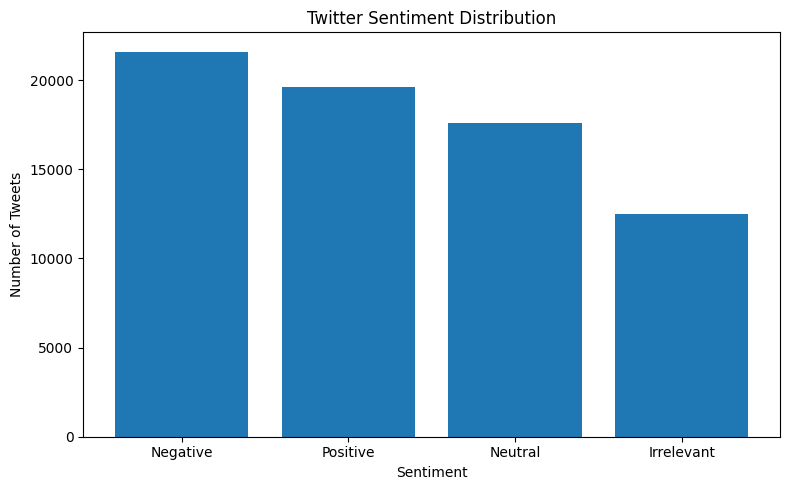

In [59]:
# --------------------------------------------
# 26. Final Sentiment Distribution
# --------------------------------------------

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.title("Twitter Sentiment Distribution")

plt.tight_layout()
plt.show()

# Key Findings

1. The Twitter dataset was successfully cleaned by removing missing
   tweet entries and duplicate records.

2. The dataset contains tweets belonging to multiple sentiment
   categories, including Positive, Negative, Neutral, and Irrelevant.

3. The tweet text was cleaned and converted into numerical TF-IDF
   features for machine learning.

4. A Logistic Regression model was trained to classify the sentiment
   of tweets.

5. The model's performance was evaluated using accuracy, precision,
   recall, F1-score, and a confusion matrix.

6. The confusion matrix and classification report provide a detailed
   view of the model's performance across the different sentiment
   categories.

# Conclusion

The Twitter Sentiment Analysis project successfully demonstrated the
use of Natural Language Processing and machine learning for sentiment
classification.

The tweets were cleaned and transformed into TF-IDF numerical
features, after which a Logistic Regression model was trained to
classify the sentiments.

The model was evaluated using accuracy, classification metrics, and a
confusion matrix. The analysis demonstrates how machine learning can
be applied to Twitter data to identify different types of sentiment
expressed in tweets.